CRAZYFLIE
=========

Test RSSI
---------


In [ ]:
import argparse
import cflib.crtp
from cflib.crtp.radio_link_statistics import RadioLinkStatistics
from cflib.crazyflie.log import LogConfig
from cflib.crazyflie import Crazyflie
from cflib.crazyflie.syncCrazyflie import SyncCrazyflie
from cflib.crazyflie.syncLogger import SyncLogger
from cflib.crazyflie.swarm import CachedCfFactory
from cflib.crazyflie.swarm import Swarm
import cflib.drivers.crazyradio as crazyradio
from cflib.utils import uri_helper

from collections import defaultdict
from dotenv import load_dotenv
import logging
import numpy as np
import sys
from threading import Event
import time

In [2]:
# ------------------------------------
# ENVIRONMENT VARIABLES
# ------------------------------------
load_dotenv('')

# URI to the Crazyflie to connect to
URIs = []
for d in range(1,4):
    URIs.append( uri_helper.uri_from_env(env=f'DRONE{str(d)}_URI', default='radio://0/80/2M/E7E7E7E7E7') )
print(URIs)

['radio://0/80/2M/E7E7E7E701', 'radio://0/80/2M/E7E7E7E702', 'radio://0/95/2M/E7E7E7E703']


In [3]:
# ------------------------------------
# STATISTICS
# ------------------------------------
link_quality = 0
def radio_stats_cb(data):
    global link_quality
    link_quality = data
    
def link_error_cb(data):
    raise Exception

In [32]:
# ------------------------------------
# LOGGING
# ------------------------------------
logging.basicConfig(level=logging.ERROR)
print("Python Version", sys.version)
print(f"Crazyradio 2.0 Version: {crazyradio.Crazyradio().version}")

from collections import defaultdict
kalman_logs = defaultdict(list)
rssi_logs = []
def log_pos_cb(timestamp, data, logconf):
    global kalman_logs
    #print('[%d][%s]: %s' % (timestamp, logconf.name, data))
    kalman_logs['kalman.stateX'].append(data['kalman.stateX'])
    kalman_logs['kalman.stateY'].append(data['kalman.stateY'])
    kalman_logs['kalman.stateZ'].append(data['kalman.stateZ'])
    
def log_radio_cb(timestamp, data, logconf):
    pass#print('[%d][%s]: %s' % (timestamp, logconf.name, data))

def log_pos_cb2(timestamp, data, logconf):
    print("-" + " POSITION LOG " + "-" * 20)
    for key, value in data.items():
        print(f"{key}: {value:2.3f}",)
    print("\n-" + "--------------" + "-" * 20)

flag_header = False
def log_radio_cb2(timestamp, data, logconf):
    global flag_header
    global link_quality
    global rssi_logs
    
    if not flag_header:
        print("|-" + " RADIO LOG " + "-" * 20)
        print("| ", end='')
        print(f"Link Quality", end=' |\t')
        for key in data.keys():
            print(f"{key}", end=' |\t')
        print("")
        flag_header = True
    print("| ", end='')
    print(f"{link_quality:2.2f}", end=f'{' '*(12-1)}|\t')
    for key, value in data.items():
        rssi_logs.append(value) if key == 'radio.rssi' else None
        print(f"{value}", end=f'{' '*(len(key)-1)}|\t')
    print("")

def log_error_cb(logconf, msg):
    print("Error when logging %s" % logconf.name)

Python Version 3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]
Crazyradio 2.0 Version: 5.4


In [5]:
# CrazyRadio devices currently connected to the computer
print("\n|- Crazyradio Devices ---" + "-" * 10)
dongles = []
for d in crazyradio._find_devices():
    print(f"|- \t{d.manufacturer}, {d.product} (Serial number: {d.serial_number})")
    dongles.append(d)
print("|------------------------" + "-" * 10)


|- Crazyradio Devices -------------
|- 	Bitcraze AB, Crazyradio 2.0 (Serial number: 57D5141CC2A4510C)
|----------------------------------


**Main**

In [6]:
radio = crazyradio.Crazyradio()

# Initialize the low-level drivers
cflib.crtp.init_drivers(enable_serial_driver=False)

# Interface status
interfaces = cflib.crtp.get_interfaces_status()
print(f"Radio Interface: {interfaces['radio']}")

Radio Interface: Crazyradio version 5.4


In [7]:
# Crazyradio Interface scanning
drones = dict() # Dictionary: { 'drone_uri': driverClass_uri}
for uri in URIs:
    drone_addr = uri.split('/')[-1]
    available = cflib.crtp.scan_interfaces(address=int(drone_addr, 16))
    if available:
        #drones.add(available[0][0])
        """
        drones[available[0][0]] = cflib.crtp.get_link_driver(
            uri=available[0][0], 
            #radio_link_statistics_callback=radio_stats_cb,
            link_error_callback=link_error_cb
        )
        """

        drones[available[0][0]] = 1
drones_uri = list(drones.keys())
print("Crazyflie available: ", drones_uri)

Crazyflie available:  ['radio://0/80/2M/E7E7E7E701']


In [8]:
drone_uri = drones_uri[0]
print("Link", drones[drone_uri])
cf_stats = Crazyflie(rw_cache='./cache')

Link 1


In [ ]:
def log_configurations():
    logconf = []

    def log_radio_conf():
        log_conf = LogConfig(name="Radio", period_in_ms=500)
        log_conf.add_variable('radio.rssi', 'uint8_t') # Radio Signal Strength Indicator [dBm]
        log_conf.add_variable('radio.isConnected', 'uint8_t') # Indicator if a packet was received from the radio within the last RADIO_ACTIVITY_TIMEOUT_MS
        log_conf.add_variable('radio.numRxBc', 'uint16_t') # Number of broadcast packets received
        log_conf.add_variable('radio.numRxUc', 'uint16_t') # Number of unicast packets received
        return log_conf
    
    def log_pos_conf():
        log_conf = LogConfig(name='Position', period_in_ms=200)
        log_conf.add_variable('kalman.stateX', 'float')
        log_conf.add_variable('kalman.stateY', 'float')
        log_conf.add_variable('kalman.stateZ', 'float')
        return log_conf
    
    def log_range_conf():
        log_conf = LogConfig(name='Range', period_in_ms=200)
        log_type = 'uint16_t' # Distance from the sensor to an obstacle in mm
        log_conf.add_variable('range.front', 'uint16_t')
        log_conf.add_variable('range.back', 'uint16_t')
        log_conf.add_variable('range.left', 'uint16_t')
        log_conf.add_variable('range.right', 'uint16_t')
        log_conf.add_variable('range.zrange', 'uint16_t')
        return log_conf
    
    def log_imu_conf():
        log_conf = LogConfig(name='Position', period_in_ms=30)
        imu_type="FP16"
        log_conf.add_variable("acc.x", imu_type)
        log_conf.add_variable("acc.y", imu_type)
        log_conf.add_variable("acc.z", imu_type)
        log_conf.add_variable("gyro.x", imu_type)
        log_conf.add_variable("gyro.y", imu_type)
        log_conf.add_variable("gyro.z", imu_type)
        
    logconf.append( log_radio_conf() )
    logconf.append( log_pos_conf() )
    logconf.append( log_range_conf() )

    return logconf

In [34]:
scf = SyncCrazyflie(drone_uri, cf=cf_stats)
print("Crazyflie - Open Link")
scf.open_link()

# ---[ Logs configuration ]---
#print("Crazyflie - Wait for params..")
#scf.wait_for_params()
log_configs = log_configurations()
print([log_conf.name for log_conf in log_configs])

# Log configuration to logging framework
for log_conf in log_configs:
    
    scf.cf.log.add_config(log_conf)

    if log_conf.valid:
        scf.cf.link_statistics.link_quality_updated.add_callback(radio_stats_cb)
        print(log_conf.name)
        match(log_conf.name):
            case "Radio":
                log_conf.data_received_cb.add_callback(log_radio_cb)
            case "Position":
                log_conf.data_received_cb.add_callback(log_pos_cb)
        
        log_conf.error_cb.add_callback(log_error_cb)
    else:
        print("One or more of the variables in the configuration was not found in log TOC. No logging will be possible.")

# ---[ Parameter configuration ]---
print("Crazyflie - Wait for params..")
scf.wait_for_params()

#radio_stats = RadioLinkStatistics(radio_link_statistics_callback=log_stat_cb, alpha=0.1)
def link_quality_cb(data):
    print(f"{data}")

#scf.cf.link_statistics.link_quality_updated.add_callback(link_quality_cb)
#scf.cf.link_statistics.stop()
for log_conf in log_configs:
    log_conf.start()

Crazyflie - Open Link
['Radio', 'Position']
Radio
Position
Crazyflie - Wait for params..


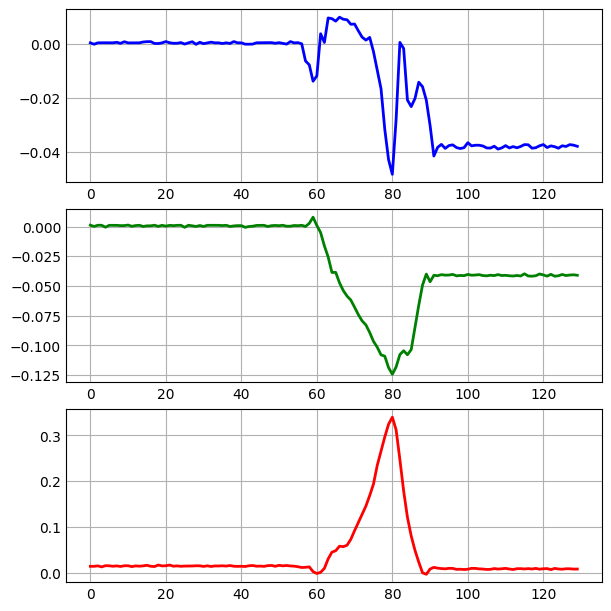

In [36]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('_mpl-gallery')

# plot
t1 = range(0,len(kalman_logs['kalman.stateX']))
t2 = range(0,len(kalman_logs['kalman.stateY']))
t3 = range(0,len(kalman_logs['kalman.stateZ']))
tt = [t3, t2, t1]
states = [kalman_logs['kalman.stateZ'], kalman_logs['kalman.stateY'], kalman_logs['kalman.stateX']]
colors = ['red', 'green', 'blue']

fig, axs = plt.subplots(3, 1, layout='constrained', figsize=(6, 6))
for nn, ax in enumerate(axs):
    t = tt.pop()
    state = states.pop()
    color = colors.pop()
    ax.plot(t, state, linewidth=2.0, color=color)

plt.show()

In [ ]:
# plot
t1 = range(0,len(kalman_logs['kalman.stateX']))
t2 = range(0,len(kalman_logs['kalman.stateY']))
t3 = range(0,len(kalman_logs['kalman.stateZ']))
tt = [t3, t2, t1]
states = [kalman_logs['kalman.stateZ'], kalman_logs['kalman.stateY'], kalman_logs['kalman.stateX']]
colors = ['red', 'green', 'blue']

fig, axs = plt.subplots(3, 1, layout='constrained', figsize=(6, 6))
for nn, ax in enumerate(axs):
    t = tt.pop()
    state = states.pop()
    color = colors.pop()
    ax.plot(t, state, linewidth=2.0, color=color)

plt.show()

In [35]:
for log_conf in log_configs:
    log_conf.stop()
scf.close_link()

defaultdict(list,
            {'kalman.stateX': [4.08199084631633e-05,
              -0.0006551782716996968,
              0.0012031723745167255,
              0.0005369347636587918,
              6.402307190001011e-05,
              0.0005619476432912052,
              0.0010330401128157973,
              0.0013046918902546167,
              0.00041875694296322763,
              0.0004386163782328367,
              0.0004917355836369097,
              0.0011682800250127912,
              0.0004906177055090666,
              6.750792090315372e-05,
              0.000283232016954571,
              0.0011481555411592126,
              -0.00029677938437089324,
              0.001341059454716742,
              0.0013675600057467818,
              0.0013781513553112745,
              0.0014212913811206818,
              0.0014834243338555098,
              0.0008531234343536198,
              0.0016220336547121406,
              0.0007056519971229136,
              -0.00016107955889310688,


In [ ]:
import random
import time
from collections import defaultdict
import pprint

def generator_kalman(seed=1.0):
    log = {'kalman.stateX': random.random(), 'kalman.stateY': random.random(), 'kalman.stateZ': random.random()}
    yield log

logs = defaultdict(list)
while True:
    try:
        new_entry = next(generator_kalman())                
        logs['kalman.stateX'].append(new_entry['kalman.stateX'])
        logs['kalman.stateY'].append(new_entry['kalman.stateY'])
        logs['kalman.stateZ'].append(new_entry['kalman.stateZ'])
        time.sleep(0.8)
    except KeyboardInterrupt:
        break

pprint.pp(logs)